# The City Premium: Wages, Cost of Living, and Real Purchasing Power

This notebook studies a concrete version of the claim:

> Moving to a large city does not automatically make a worker richer.

The goal is not to prove that cities are bad. The goal is to test whether the nominal wage premium in large metropolitan areas survives after adjusting for local price levels.

We will use public data:

- **BLS OEWS**: metropolitan occupation-level wages.
- **BEA/FRED Regional Price Parities**: local price levels relative to the U.S. average.
- Optional manual extension: **MIT Living Wage Calculator** for a small number of hand-entered locations, without scraping.

The main quantity of interest is the difference between:

1. the **nominal wage premium** of a city, and
2. the **cost-adjusted wage premium**, after accounting for local price levels.

This notebook is written to be extended. It is not a closed analysis.

> **Headline (May 2024 BLS OEWS + 2024 BEA RPP, 145 metros).** The nominal city premium is almost universal but the *real* premium is not. San Jose leads on purchasing power; San Francisco's wages survive its high prices, but in Los Angeles only ~47% of workers come out ahead of Tulsa after cost adjustment, and Miami pairs near-top prices with bottom-tier real wages. High-skill occupations keep a large real premium; low-wage service jobs (e.g. NYC retail) can go negative.

## Research design

For each metropolitan area and occupation, we ask:

1. How much higher is the nominal wage in a high-cost city?
2. How much of that premium disappears after adjusting by regional prices?
3. Which occupations gain from cities?
4. Which occupations earn more nominally but not in real purchasing-power terms?
5. What share of local employment is in occupations where the city premium is positive after cost adjustment?

The basic adjustment is:

\[
\text{real wage}_{m,o} =
\frac{\text{nominal wage}_{m,o}}{\text{RPP}_m / 100}
\]

where:

- \(m\) is the metropolitan area,
- \(o\) is the occupation,
- RPP is the BEA Regional Price Parity index.

An RPP above 100 means the area is more expensive than the national average.
An RPP below 100 means it is cheaper than the national average.

## Important limitations

This is an economic comparison, not a complete life decision model.

The notebook does **not** fully capture:

- career learning and network effects;
- long-run promotion probability;
- local taxes at fine geographic level;
- housing tenure differences, such as renting versus owning;
- household composition;
- childcare needs;
- quality of public services;
- social and cultural preferences;
- immigration constraints;
- remote-work effects.

The model is still useful because it makes the wage-cost tradeoff explicit.

In [1]:
from __future__ import annotations

import io
import re
import time
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

# OEWS metropolitan files are released roughly one year after the reference
# period. As of mid-2026 the most recent published metro file is May 2024
# (oesm24ma). Bump this when BLS publishes a newer one.
OEWS_YEAR: int = 2024
RPP_YEAR: int = 2024  # latest published BEA Regional Price Parities vintage

# Keep the first run manageable. Set to True if you want to scan every metro.
RUN_FULL_AREA_SCAN: bool = False

# Number of top employment metros to fetch from FRED when not doing a full scan.
# ~150 covers every large metro that has a published RPP series, which is enough
# for a representative national scatter without hammering FRED.
MAX_RPP_AREAS: int = 150

# Local cache. This avoids downloading the same files repeatedly.
# Resolve paths against the project root so the notebook works whether it is
# run from the project folder or from notebooks/.
PROJECT_DIR: Path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR: Path = PROJECT_DIR / "data"
RAW_DIR: Path = DATA_DIR / "raw"
PROCESSED_DIR: Path = DATA_DIR / "processed"
FRED_CACHE_DIR: Path = RAW_DIR / "fred"
OUTPUT_DIR: Path = PROJECT_DIR / "outputs"

for path in [RAW_DIR, PROCESSED_DIR, FRED_CACHE_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# A small case-study set used in the first pass.
# Area codes are CBSA codes used by BLS and usually by FRED/BEA RPP series IDs.
CASE_STUDY_AREAS: dict[str, str] = {
    "New York-Newark-Jersey City, NY-NJ-PA": "35620",
    "Tulsa, OK": "46140",
    "Spokane-Spokane Valley, WA": "44060",
    "San Francisco-Oakland-Fremont, CA": "41860",
    "Los Angeles-Long Beach-Anaheim, CA": "31080",
    "Boston-Cambridge-Newton, MA-NH": "14460",
    "Seattle-Tacoma-Bellevue, WA": "42660",
    "Austin-Round Rock-San Marcos, TX": "12420",
    "Dallas-Fort Worth-Arlington, TX": "19100",
    "Washington-Arlington-Alexandria, DC-VA-MD-WV": "47900",
    "Chicago-Naperville-Elgin, IL-IN-WI": "16980",
    "Denver-Aurora-Centennial, CO": "19740",
}

# Occupations to highlight. The notebook can still use all occupations.
FOCUS_OCCUPATIONS: dict[str, str] = {
    "00-0000": "All occupations",
    "15-2051": "Data Scientists",
    "15-1252": "Software Developers",
    "29-1141": "Registered Nurses",
    "25-2021": "Elementary School Teachers, Except Special Education",
    "43-6014": "Secretaries and Administrative Assistants, Except Legal, Medical, and Executive",
    "41-2031": "Retail Salespersons",
    "35-3023": "Fast Food and Counter Workers",
    "31-1120": "Home Health and Personal Care Aides",
}

In [3]:
# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

# BLS serves files behind a bot filter that rejects the default requests
# User-Agent with a 403 "Access Denied" page. A browser-like User-Agent is
# required for the download to succeed.
BROWSER_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
    ),
    "Accept": "*/*",
}


def assert_non_empty_string(value: str, name: str) -> None:
    """Validate that a value is a non-empty string."""
    if not isinstance(value, str) or not value.strip():
        raise TypeError(f"{name} must be a non-empty string.")


def safe_numeric(series: pd.Series) -> pd.Series:
    """Convert BLS-style numeric text to floats.

    BLS files sometimes use symbols such as '*', '#', or unavailable values.
    Those are converted to NaN.
    """
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.replace(
        {
            "*": np.nan,
            "#": np.nan,
            "**": np.nan,
            "~": np.nan,
            "nan": np.nan,
            "NaN": np.nan,
            "": np.nan,
        }
    )
    return pd.to_numeric(cleaned, errors="coerce")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with lower-case snake-like column names."""
    out = df.copy()
    out.columns = [
        re.sub(r"[^a-z0-9]+", "_", str(col).strip().lower()).strip("_")
        for col in out.columns
    ]
    return out


def download_bytes(url: str, timeout: int = 180) -> bytes:
    """Download bytes from a URL with a browser-like User-Agent."""
    assert_non_empty_string(url, "url")
    response = requests.get(url, timeout=timeout, headers=BROWSER_HEADERS)
    response.raise_for_status()
    return response.content


def read_metro_table_from_zip(content: bytes) -> pd.DataFrame:
    """Read the metropolitan-area table from an OEWS ZIP archive.

    The OEWS metro ZIP bundles several files, e.g.

        oesm24ma/BOS_M2024_dl.xlsx          (balance-of-state / nonmetro areas)
        oesm24ma/MSA_M2024_dl.xlsx          (metropolitan statistical areas)
        oesm24ma/file_descriptions.xlsx     (data dictionary)

    We must pick the MSA file. The nonmetro ("BOS") file uses 7-digit area
    codes that never match BEA/FRED RPP series, and ``file_descriptions`` is a
    schema sheet, so naively reading the first ``.xlsx`` silently breaks the
    whole analysis. We therefore select by name, preferring an "MSA" file and
    explicitly skipping the dictionary and macOS metadata.
    """
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        names = [n for n in zf.namelist() if not n.endswith("/")]
        lower = {n: n.lower() for n in names}

        def pick(extensions: tuple[str, ...]) -> str | None:
            candidates = [
                n for n in names
                if lower[n].endswith(extensions)
                and "__macosx" not in lower[n]
                and "file_description" not in lower[n]
            ]
            if not candidates:
                return None
            # Prefer the metropolitan-area file when several data files exist.
            msa = [n for n in candidates if "msa" in lower[n]]
            return (msa or candidates)[0]

        for extensions, reader in (
            ((".xlsx", ".xls"), lambda fh: pd.read_excel(fh, dtype=str)),
            ((".csv",), lambda fh: pd.read_csv(fh, dtype=str)),
            ((".txt", ".tsv"), lambda fh: pd.read_csv(fh, sep="\t", dtype=str)),
        ):
            name = pick(extensions)
            if name is not None:
                with zf.open(name) as fh:
                    return reader(fh)

    raise ValueError("No metro data table (xlsx/csv/txt) found inside the ZIP archive.")

In [4]:
# ---------------------------------------------------------------------
# Load BLS OEWS metropolitan wage data
# ---------------------------------------------------------------------

def discover_oews_metro_urls_from_bls_page(year: int) -> list[str]:
    """Try to discover the current OEWS metro ZIP link from the BLS tables page."""
    yy = str(year)[-2:]
    expected = f"oesm{yy}ma.zip"
    tables_url = "https://www.bls.gov/oes/tables.htm"

    try:
        html = requests.get(tables_url, timeout=60, headers=BROWSER_HEADERS).text
    except Exception:
        return []

    # Find any href containing the expected file name.
    matches = re.findall(r'href=["\']([^"\']*' + re.escape(expected) + r')["\']', html)
    return [urljoin(tables_url, match) for match in matches]


def wayback_fallback_url(original_url: str) -> str | None:
    """Return a raw Wayback Machine snapshot URL for ``original_url``, if any.

    BLS blocks automated downloads from many networks (data centres, cloud IPs)
    with a 403 page even with a browser User-Agent. The Internet Archive mirrors
    these public files, so we fall back to the closest snapshot. The ``id_``
    suffix asks Wayback for the original bytes rather than a rewritten page.
    """
    try:
        api = f"http://archive.org/wayback/available?url={original_url}"
        snap = requests.get(api, timeout=60).json()
        closest = snap.get("archived_snapshots", {}).get("closest", {})
        if closest.get("available") and closest.get("url"):
            return re.sub(r"/web/(\d+)/", r"/web/\1id_/", closest["url"], count=1)
    except Exception:
        return None
    return None


def oews_metro_candidate_urls(year: int) -> list[str]:
    """Return plausible BLS OEWS metro file URLs for a given year.

    BLS has historically used both 'special.requests' and 'special-requests'
    URL patterns. We try the live BLS page, then the canonical paths, then the
    Internet Archive mirror of each as a last resort.
    """
    if not isinstance(year, int) or year < 2000:
        raise ValueError("year must be an integer >= 2000.")

    yy = str(year)[-2:]
    filename = f"oesm{yy}ma.zip"

    discovered = discover_oews_metro_urls_from_bls_page(year)
    direct = [
        *discovered,
        f"https://www.bls.gov/oes/special.requests/{filename}",
        f"https://www.bls.gov/oes/special-requests/{filename}",
        f"https://www.bls.gov/oes/current/{filename}",
    ]

    # Add a Wayback Machine fallback for each direct URL.
    archived = [u for u in (wayback_fallback_url(d) for d in direct) if u]

    # Preserve order while dropping duplicates.
    return list(dict.fromkeys([*direct, *archived]))


def load_oews_metro(year: int = OEWS_YEAR, cache: bool = True) -> pd.DataFrame:
    """Load BLS OEWS metropolitan area wage data.

    Returns a normalized DataFrame with numeric wage and employment fields.
    Caches both the raw ZIP (``data/raw/oesm{yy}ma.zip``) and the parsed
    parquet so re-runs are fast and offline-friendly.
    """
    cache_path = RAW_DIR / f"oews_metro_{year}.parquet"
    if cache and cache_path.exists():
        return pd.read_parquet(cache_path)

    yy = str(year)[-2:]
    zip_path = RAW_DIR / f"oesm{yy}ma.zip"

    raw_df: pd.DataFrame | None = None
    errors: list[str] = []

    # 1. Reuse a previously downloaded raw ZIP if present.
    if zip_path.exists():
        try:
            raw_df = read_metro_table_from_zip(zip_path.read_bytes())
            print(f"Loaded OEWS data from local cache: {zip_path}")
        except Exception as exc:
            errors.append(f"{zip_path} -> {type(exc).__name__}: {exc}")

    # 2. Otherwise download from BLS (or the Wayback mirror).
    if raw_df is None:
        for url in oews_metro_candidate_urls(year):
            try:
                print(f"Trying: {url}")
                content = download_bytes(url)
                raw_df = read_metro_table_from_zip(content)
                zip_path.write_bytes(content)
                print(f"Loaded OEWS data from: {url}")
                break
            except Exception as exc:
                errors.append(f"{url} -> {type(exc).__name__}: {exc}")

    if raw_df is None:
        joined_errors = "\n".join(errors)
        raise RuntimeError(
            "Could not load BLS OEWS metropolitan data.\n"
            "Tried these sources:\n"
            f"{joined_errors}\n\n"
            "If BLS blocks your network, download the metro ZIP manually from\n"
            "https://www.bls.gov/oes/tables.htm and place it at\n"
            f"{zip_path}, then re-run this cell."
        )

    df = normalize_columns(raw_df)

    required = {"area", "area_title", "occ_code", "occ_title"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing expected OEWS columns: {sorted(missing)}")

    # Convert key numeric fields when present.
    for col in ["tot_emp", "jobs_1000", "loc_quotient", "h_mean", "a_mean", "h_median", "a_median"]:
        if col in df.columns:
            df[col] = safe_numeric(df[col])

    # Standardize area code as string.
    df["area"] = df["area"].astype(str).str.zfill(5)

    # Keep rows that look like metropolitan CBSA codes. The MSA file uses
    # 5-digit codes; this guards against accidentally loading a nonmetro file.
    df["is_cbsa_like"] = df["area"].str.fullmatch(r"\d{5}")

    if cache:
        df.to_parquet(cache_path, index=False)

    return df


oews = load_oews_metro()
print(f"OEWS rows: {len(oews):,} | metro-coded rows: {int(oews['is_cbsa_like'].sum()):,}")
oews.head()

OEWS rows: 150,176 | metro-coded rows: 150,176


,area,area_title,area_type,prim_state,naics,naics_title,i_group,own_code,occ_code,occ_title,...,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly,is_cbsa_like
0,10180,"Abilene, TX",4,TX,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,29.34,45.3,23120,29640,42120.0,61020,94220,None,None,True
1,10180,"Abilene, TX",4,TX,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,61.17,84.3,44710,61250,87420.0,127230,175350,None,None,True
2,10180,"Abilene, TX",4,TX,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,#,#,99140,107040,177520.0,#,#,None,None,True
3,10180,"Abilene, TX",4,TX,000000,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,58.64,87.22,35980,50640,77340.0,121970,181420,None,None,True
4,10180,"Abilene, TX",4,TX,000000,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,73.86,99.9,58480,82560,104030.0,153630,207790,None,None,True


## Build the metro universe

We start with all-occupation rows. These represent the local labor market aggregate and are useful for ranking cities before drilling down by occupation.

In [5]:
all_occ = (
    oews.loc[(oews["occ_code"] == "00-0000") & (oews["is_cbsa_like"])]
    .copy()
)

# Keep only rows with a usable annual median wage.
all_occ = all_occ.dropna(subset=["a_median"])

metro_summary = (
    all_occ[["area", "area_title", "tot_emp", "a_mean", "a_median", "h_mean", "h_median"]]
    .drop_duplicates("area")
    .sort_values("tot_emp", ascending=False)
    .reset_index(drop=True)
)

display(metro_summary.head(20))
print(f"Metro-like areas with all-occupation wages: {metro_summary['area'].nunique():,}")

,area,area_title,tot_emp,a_mean,a_median,h_mean,h_median
0,35620,"New York-Newark-Jersey City, NY-NJ",9363020.0,84560.0,60460.0,40.65,29.07
1,31080,"Los Angeles-Long Beach-Anaheim, CA",6199940.0,76200.0,53490.0,36.64,25.72
2,16980,"Chicago-Naperville-Elgin, IL-IN",4473740.0,71600.0,51510.0,34.42,24.76
3,19100,"Dallas-Fort Worth-Arlington, TX",4003820.0,68420.0,49740.0,32.89,23.91
4,26420,"Houston-Pasadena-The Woodlands, TX",3246360.0,66280.0,48490.0,31.87,23.31
5,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",3118630.0,90420.0,68430.0,43.47,32.90
6,12060,"Atlanta-Sandy Springs-Roswell, GA",2871980.0,70150.0,49770.0,33.73,23.93
7,37980,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",2868720.0,69620.0,51760.0,33.47,24.89
8,33100,"Miami-Fort Lauderdale-West Palm Beach, FL",2782340.0,66310.0,47920.0,31.88,23.04
9,14460,"Boston-Cambridge-Newton, MA-NH",2707940.0,87040.0,64620.0,41.85,31.07


Metro-like areas with all-occupation wages: 393


## Load BEA/FRED Regional Price Parities

BEA Regional Price Parities compare local price levels to the U.S. national average.

FRED mirrors many BEA RPP series. For MSA-level all-items RPP, the series ID usually follows:

\[
\texttt{RPPALL} + \text{CBSA code}
\]

For housing services/rents RPP, the series ID usually follows:

\[
\texttt{RPPSERVERENT} + \text{CBSA code}
\]

The notebook uses FRED CSV endpoints because they do not require an API key. This is practical for reproducibility.

In [6]:
# ---------------------------------------------------------------------
# FRED / BEA RPP loader
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class RPPRecord:
    """Regional Price Parity record for a metropolitan area."""
    area: str
    rpp_all: float | None
    rpp_rent: float | None
    rpp_year: int


def fred_series_csv_url(series_id: str) -> str:
    """Build a FRED CSV download URL for a series."""
    assert_non_empty_string(series_id, "series_id")
    return f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"


def load_fred_series(series_id: str, cache: bool = True) -> pd.DataFrame:
    """Load a FRED series as a DataFrame.

    The downloaded CSV has a date column and one value column named after the
    series.
    """
    assert_non_empty_string(series_id, "series_id")
    cache_path = FRED_CACHE_DIR / f"{series_id}.csv"

    if cache and cache_path.exists():
        return pd.read_csv(cache_path)

    url = fred_series_csv_url(series_id)
    df = pd.read_csv(url)

    if cache:
        df.to_csv(cache_path, index=False)

    # Avoid hammering FRED when doing larger scans.
    time.sleep(0.05)
    return df


def latest_or_year_value(series_id: str, year: int = RPP_YEAR) -> float | None:
    """Return a FRED annual series value for a target year, or latest available.

    FRED's CSV export has used both ``DATE`` and ``observation_date`` as the
    date column header over time, so we detect it instead of hard-coding it.
    """
    try:
        df = load_fred_series(series_id)
    except Exception:
        return None

    if series_id not in df.columns:
        return None

    # Detect the date column across FRED CSV schema versions.
    date_col = next(
        (c for c in ("observation_date", "DATE", "date") if c in df.columns),
        df.columns[0],
    )

    out = df.copy()
    out["year"] = pd.to_datetime(out[date_col], errors="coerce").dt.year
    out[series_id] = pd.to_numeric(out[series_id], errors="coerce")
    out = out.dropna(subset=[series_id, "year"])

    target = out.loc[out["year"] == year, series_id]
    if not target.empty:
        return float(target.iloc[-1])

    if out.empty:
        return None

    return float(out.sort_values("year")[series_id].iloc[-1])


def load_rpp_for_area(area_code: str, year: int = RPP_YEAR) -> RPPRecord:
    """Load all-items and rent RPP values for one CBSA area code."""
    assert_non_empty_string(area_code, "area_code")
    code = area_code.zfill(5)

    rpp_all = latest_or_year_value(f"RPPALL{code}", year=year)
    rpp_rent = latest_or_year_value(f"RPPSERVERENT{code}", year=year)

    return RPPRecord(area=code, rpp_all=rpp_all, rpp_rent=rpp_rent, rpp_year=year)


def load_rpp_for_areas(area_codes: Sequence[str], year: int = RPP_YEAR) -> pd.DataFrame:
    """Load RPP values for multiple CBSA area codes."""
    if not isinstance(area_codes, Sequence):
        raise TypeError("area_codes must be a sequence of strings.")

    records: list[RPPRecord] = []
    for i, area_code in enumerate(area_codes, start=1):
        print(f"[{i:03d}/{len(area_codes):03d}] Loading RPP for area {area_code}")
        records.append(load_rpp_for_area(str(area_code), year=year))

    return pd.DataFrame([record.__dict__ for record in records])


case_area_codes = list(CASE_STUDY_AREAS.values())

if RUN_FULL_AREA_SCAN:
    area_codes_to_fetch = metro_summary["area"].tolist()
else:
    top_area_codes = metro_summary.head(MAX_RPP_AREAS)["area"].tolist()
    area_codes_to_fetch = sorted(set(case_area_codes + top_area_codes))

rpp = load_rpp_for_areas(area_codes_to_fetch)
rpp = rpp.dropna(subset=["rpp_all"]).reset_index(drop=True)

display(rpp.head())
print(f"Areas with RPP all-items values: {rpp['area'].nunique():,}")

[001/150] Loading RPP for area 10420
[002/150] Loading RPP for area 10580
[003/150] Loading RPP for area 10740
[004/150] Loading RPP for area 10900
[005/150] Loading RPP for area 11260
[006/150] Loading RPP for area 11460


[007/150] Loading RPP for area 11700
[008/150] Loading RPP for area 12060


[009/150] Loading RPP for area 12100
[010/150] Loading RPP for area 12260
[011/150] Loading RPP for area 12420
[012/150] Loading RPP for area 12540
[013/150] Loading RPP for area 12580


[014/150] Loading RPP for area 12940


[015/150] Loading RPP for area 13140
[016/150] Loading RPP for area 13820
[017/150] Loading RPP for area 14260
[018/150] Loading RPP for area 14460
[019/150] Loading RPP for area 14500
[020/150] Loading RPP for area 14860


...

[137/150] Loading RPP for area 45940
[138/150] Loading RPP for area 46060
[139/150] Loading RPP for area 46140
[140/150] Loading RPP for area 46520
[141/150] Loading RPP for area 47260
[142/150] Loading RPP for area 47300
[143/150] Loading RPP for area 47900


[144/150] Loading RPP for area 47930


[145/150] Loading RPP for area 48620
[146/150] Loading RPP for area 48900
[147/150] Loading RPP for area 49180
[148/150] Loading RPP for area 49340
[149/150] Loading RPP for area 49620
[150/150] Loading RPP for area 49660


,area,rpp_all,rpp_rent,rpp_year
0,10420,93.370,76.785,2024
1,10580,99.566,102.582,2024
2,10740,95.546,89.153,2024
3,10900,99.968,105.520,2024
4,11260,105.420,109.905,2024


Areas with RPP all-items values: 145


## Merge wages and local prices

The key fields:

- `a_median`: annual median wage.
- `rpp_all`: all-items Regional Price Parity.
- `real_a_median`: annual median wage adjusted for local price level.
- `rent_pressure_index`: housing/rent RPP relative to all-items RPP.

A city can look good nominally while looking mediocre after price adjustment.

In [7]:
metro_real = (
    metro_summary
    .merge(rpp, on="area", how="inner")
    .assign(
        real_a_median=lambda x: x["a_median"] / (x["rpp_all"] / 100.0),
        real_a_mean=lambda x: x["a_mean"] / (x["rpp_all"] / 100.0),
        rent_pressure_index=lambda x: x["rpp_rent"] / x["rpp_all"],
    )
    .sort_values("real_a_median", ascending=False)
    .reset_index(drop=True)
)

cols = [
    "area",
    "area_title",
    "tot_emp",
    "a_median",
    "rpp_all",
    "real_a_median",
    "rpp_rent",
    "rent_pressure_index",
]

display(metro_real[cols].head(20))

,area,area_title,tot_emp,a_median,rpp_all,real_a_median,rpp_rent,rent_pressure_index
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",1134660.0,82470.0,110.423,74685.527472,211.901,1.918993
1,14500,"Boulder, CO",195570.0,67510.0,105.202,64171.783806,157.020,1.492557
2,41860,"San Francisco-Oakland-Fremont, CA",2405740.0,73960.0,115.613,63972.044666,194.718,1.684222
3,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",3118630.0,68430.0,108.884,62846.699240,151.134,1.388028
4,20500,"Durham-Chapel Hill, NC",342530.0,59740.0,97.572,61226.581396,98.934,1.013959
5,42660,"Seattle-Tacoma-Bellevue, WA",2082610.0,67510.0,111.133,60747.032835,151.314,1.361558
6,45940,"Trenton-Princeton, NJ",239220.0,62610.0,103.180,60680.364412,135.082,1.309188
7,14460,"Boston-Cambridge-Newton, MA-NH",2707940.0,64620.0,108.266,59686.328118,148.424,1.370920
8,19740,"Denver-Aurora-Centennial, CO",1618390.0,61110.0,105.782,57769.752888,146.919,1.388885
9,25540,"Hartford-West Hartford-East Hartford, CT",592620.0,59270.0,102.746,57685.943978,110.234,1.072879


In [8]:
# Ranking by nominal wages vs real wages

nominal_rank = (
    metro_real[cols]
    .sort_values("a_median", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

real_rank = (
    metro_real[cols]
    .sort_values("real_a_median", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("Top 20 by nominal annual median wage")
display(nominal_rank)

print("Top 20 by cost-adjusted annual median wage")
display(real_rank)

Top 20 by nominal annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median,rpp_rent,rent_pressure_index
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",1134660.0,82470.0,110.423,74685.527472,211.901,1.918993
1,41860,"San Francisco-Oakland-Fremont, CA",2405740.0,73960.0,115.613,63972.044666,194.718,1.684222
2,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",3118630.0,68430.0,108.884,62846.699240,151.134,1.388028
3,14500,"Boulder, CO",195570.0,67510.0,105.202,64171.783806,157.020,1.492557
4,42660,"Seattle-Tacoma-Bellevue, WA",2082610.0,67510.0,111.133,60747.032835,151.314,1.361558
5,14460,"Boston-Cambridge-Newton, MA-NH",2707940.0,64620.0,108.266,59686.328118,148.424,1.370920
6,45940,"Trenton-Princeton, NJ",239220.0,62610.0,103.180,60680.364412,135.082,1.309188
7,19740,"Denver-Aurora-Centennial, CO",1618390.0,61110.0,105.782,57769.752888,146.919,1.388885
8,35620,"New York-Newark-Jersey City, NY-NJ",9363020.0,60460.0,112.563,53712.143422,148.616,1.320292
9,14860,"Bridgeport-Stamford-Danbury, CT",402330.0,60440.0,106.864,56557.867944,150.453,1.407892


Top 20 by cost-adjusted annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median,rpp_rent,rent_pressure_index
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",1134660.0,82470.0,110.423,74685.527472,211.901,1.918993
1,14500,"Boulder, CO",195570.0,67510.0,105.202,64171.783806,157.020,1.492557
2,41860,"San Francisco-Oakland-Fremont, CA",2405740.0,73960.0,115.613,63972.044666,194.718,1.684222
3,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",3118630.0,68430.0,108.884,62846.699240,151.134,1.388028
4,20500,"Durham-Chapel Hill, NC",342530.0,59740.0,97.572,61226.581396,98.934,1.013959
5,42660,"Seattle-Tacoma-Bellevue, WA",2082610.0,67510.0,111.133,60747.032835,151.314,1.361558
6,45940,"Trenton-Princeton, NJ",239220.0,62610.0,103.180,60680.364412,135.082,1.309188
7,14460,"Boston-Cambridge-Newton, MA-NH",2707940.0,64620.0,108.266,59686.328118,148.424,1.370920
8,19740,"Denver-Aurora-Centennial, CO",1618390.0,61110.0,105.782,57769.752888,146.919,1.388885
9,25540,"Hartford-West Hartford-East Hartford, CT",592620.0,59270.0,102.746,57685.943978,110.234,1.072879


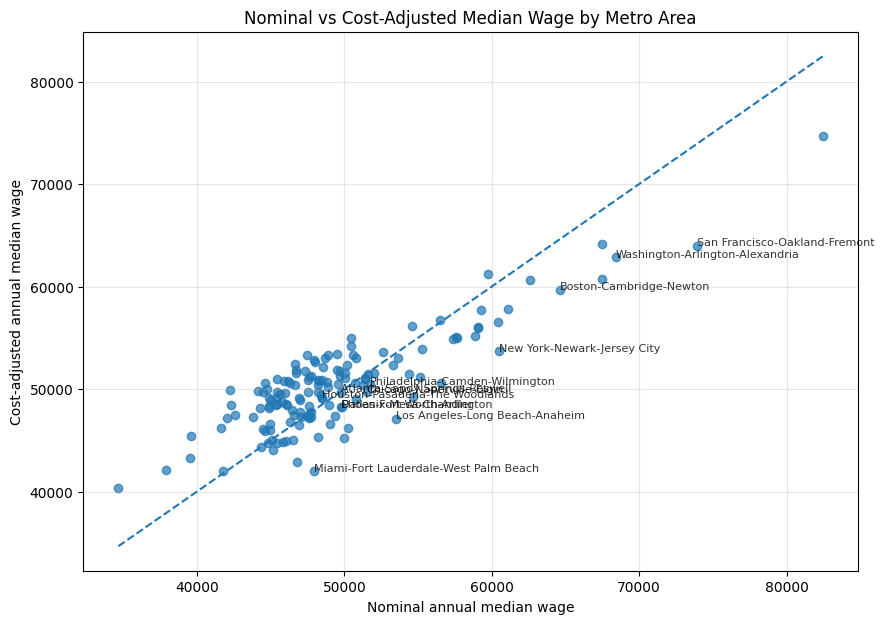

In [9]:
# Plot: nominal vs real median wage

plot_df = metro_real.dropna(subset=["a_median", "real_a_median"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df["a_median"], plot_df["real_a_median"], alpha=0.7)
ax.plot(
    [plot_df["a_median"].min(), plot_df["a_median"].max()],
    [plot_df["a_median"].min(), plot_df["a_median"].max()],
    linestyle="--",
)
ax.set_title("Nominal vs Cost-Adjusted Median Wage by Metro Area")
ax.set_xlabel("Nominal annual median wage")
ax.set_ylabel("Cost-adjusted annual median wage")
ax.grid(True, alpha=0.3)

for _, row in plot_df.sort_values("tot_emp", ascending=False).head(12).iterrows():
    ax.annotate(
        row["area_title"].split(",")[0],
        (row["a_median"], row["real_a_median"]),
        fontsize=8,
        alpha=0.8,
    )

plt.show()

**What the scatter shows.** Points below the 45&deg; line are metros where local
prices erode the nominal wage. The highest-wage coastal metros sit furthest below
it: San Francisco's \$74.0k nominal median becomes \$64.0k real, dropping it
below lower-cost **Boulder** and **Durham&ndash;Chapel Hill**. **San Jose** is
the rare metro that stays near the top on both axes. The metros pulled *down*
hardest relative to their wage are the high-RPP, ordinary-wage ones &mdash;
**Miami** most of all.

## City tax comparison

The city-tax idea can be operationalized as follows.

For the same occupation in two areas:

\[
\text{required city wage} =
\text{reference wage} \times
\frac{\text{RPP}_{city}}{\text{RPP}_{reference}}
\]

Then:

\[
\text{real net premium} =
\text{city wage} - \text{required city wage}
\]

If this is positive, the city wage more than compensates for the higher price level.
If it is negative, the worker earns more nominally but loses purchasing power.

In [10]:
def occupation_area_table(
    oews_df: pd.DataFrame,
    area_codes: Sequence[str],
    occ_codes: Sequence[str] | None = None,
) -> pd.DataFrame:
    """Return occupation-level wage rows for selected areas and occupations."""
    if occ_codes is None:
        occ_codes = sorted(FOCUS_OCCUPATIONS)

    areas = {str(code).zfill(5) for code in area_codes}
    occs = set(occ_codes)

    subset = oews_df.loc[
        oews_df["area"].isin(areas) & oews_df["occ_code"].isin(occs)
    ].copy()

    for col in ["a_median", "a_mean", "tot_emp"]:
        if col in subset.columns:
            subset[col] = safe_numeric(subset[col])

    subset = subset.dropna(subset=["a_median"])
    return subset


def compare_city_to_reference(
    wages: pd.DataFrame,
    rpp_df: pd.DataFrame,
    city_area: str,
    reference_area: str,
    occ_codes: Sequence[str] | None = None,
) -> pd.DataFrame:
    """Compare occupation wages in one city against a reference metro."""
    city_area = str(city_area).zfill(5)
    reference_area = str(reference_area).zfill(5)

    selected = occupation_area_table(
        wages,
        area_codes=[city_area, reference_area],
        occ_codes=occ_codes,
    )

    wide = selected.pivot_table(
        index=["occ_code", "occ_title"],
        columns="area",
        values=["a_median", "tot_emp"],
        aggfunc="first",
    )

    # Flatten MultiIndex columns.
    wide.columns = [f"{metric}_{area}" for metric, area in wide.columns]
    wide = wide.reset_index()

    rpp_lookup = rpp_df.set_index("area")["rpp_all"].to_dict()

    city_rpp = rpp_lookup.get(city_area)
    ref_rpp = rpp_lookup.get(reference_area)

    if city_rpp is None or ref_rpp is None:
        raise ValueError("Missing RPP value for city or reference area.")

    city_wage_col = f"a_median_{city_area}"
    ref_wage_col = f"a_median_{reference_area}"

    wide["city_area"] = city_area
    wide["reference_area"] = reference_area
    wide["city_rpp"] = city_rpp
    wide["reference_rpp"] = ref_rpp
    wide["nominal_wage_premium"] = wide[city_wage_col] - wide[ref_wage_col]
    wide["required_city_wage_for_equal_purchasing_power"] = (
        wide[ref_wage_col] * city_rpp / ref_rpp
    )
    wide["real_net_premium"] = (
        wide[city_wage_col]
        - wide["required_city_wage_for_equal_purchasing_power"]
    )
    wide["real_net_premium_pct_of_reference_wage"] = (
        wide["real_net_premium"] / wide[ref_wage_col]
    )

    return wide.sort_values("real_net_premium", ascending=False)


NYC = "35620"
TULSA = "46140"
SPOKANE = "44060"
SF = "41860"

nyc_vs_tulsa = compare_city_to_reference(
    oews,
    rpp,
    city_area=NYC,
    reference_area=TULSA,
    occ_codes=list(FOCUS_OCCUPATIONS.keys()),
)

display(nyc_vs_tulsa)

,occ_code,occ_title,a_median_35620,a_median_46140,tot_emp_35620,tot_emp_46140,city_area,reference_area,city_rpp,reference_rpp,nominal_wage_premium,required_city_wage_for_equal_purchasing_power,real_net_premium,real_net_premium_pct_of_reference_wage
3,25-2021,"Elementary School Teachers, Except Special Edu...",95240.0,49460.0,100040.0,4050.0,35620,46140,112.563,89.214,45780.0,62404.622369,32835.377631,0.663877
2,15-2051,Data Scientists,130710.0,80950.0,19810.0,690.0,35620,46140,112.563,89.214,49760.0,102136.154079,28573.845921,0.352981
1,15-1252,Software Developers,161970.0,109190.0,119610.0,2170.0,35620,46140,112.563,89.214,52780.0,137767.098998,24202.901002,0.221659
4,29-1141,Registered Nurses,113490.0,82130.0,195470.0,9600.0,35620,46140,112.563,89.214,31360.0,103624.982514,9865.017486,0.120115
5,31-1120,Home Health and Personal Care Aides,37990.0,27220.0,605590.0,5450.0,35620,46140,112.563,89.214,10770.0,34343.991526,3646.008474,0.133946
0,00-0000,All Occupations,60460.0,45460.0,9363020.0,453400.0,35620,46140,112.563,89.214,15000.0,57357.746318,3102.253682,0.068241
6,35-3023,Fast Food and Counter Workers,35420.0,26360.0,175790.0,13010.0,35620,46140,112.563,89.214,9060.0,33258.913175,2161.086825,0.081984
8,43-6014,"Secretaries and Administrative Assistants, Exc...",50990.0,39450.0,122270.0,4730.0,35620,46140,112.563,89.214,11540.0,49774.815051,1215.184949,0.030803
7,41-2031,Retail Salespersons,37350.0,29990.0,212470.0,11770.0,35620,46140,112.563,89.214,7360.0,37838.953191,-488.953191,-0.016304


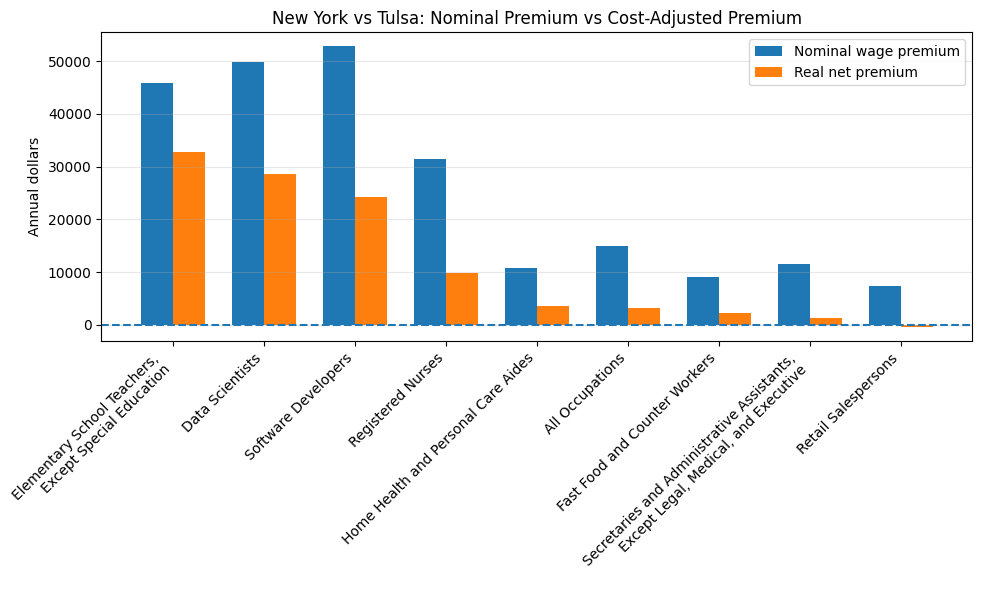

In [11]:
# Visual comparison for the focus occupations

comparison = nyc_vs_tulsa.dropna(subset=["nominal_wage_premium", "real_net_premium"]).copy()
comparison["label"] = comparison["occ_title"].str.replace(", Except", ",\nExcept", regex=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width / 2, comparison["nominal_wage_premium"], width, label="Nominal wage premium")
ax.bar(x + width / 2, comparison["real_net_premium"], width, label="Real net premium")
ax.axhline(0, linestyle="--")
ax.set_title("New York vs Tulsa: Nominal Premium vs Cost-Adjusted Premium")
ax.set_ylabel("Annual dollars")
ax.set_xticks(x)
ax.set_xticklabels(comparison["label"], rotation=45, ha="right")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Same two cities, opposite verdicts by occupation.** The nominal bars (left of
each pair) are positive for everyone &mdash; New York pays more than Tulsa in
every focus occupation. The real bars (right) tell a different story: data
scientists, software developers and teachers keep a five-figure real premium,
while **retail salespersons turn negative** (a \$7.4k nominal raise becomes a
&minus;\$489 real loss) and fast-food and home-health gains shrink to a few
thousand dollars. The city premium is steeply progressive in skill.

## Employment-weighted result

The next step avoids cherry-picking one or two occupations.

For a chosen city and reference area, we compare all occupations that exist in both places and ask:

> What share of the city's employment is in occupations where the city pays a positive real premium?

This is closer to the article's central claim.

In [12]:
def employment_weighted_city_result(
    wages: pd.DataFrame,
    rpp_df: pd.DataFrame,
    city_area: str,
    reference_area: str,
    min_city_employment: float = 100,
) -> pd.DataFrame:
    """Compare all shared occupations and compute employment-weighted outcomes.

    Parameters
    ----------
    wages:
        BLS OEWS wage table.
    rpp_df:
        Regional Price Parity table.
    city_area:
        City CBSA code.
    reference_area:
        Reference CBSA code.
    min_city_employment:
        Occupations with city employment below this are excluded to reduce noise.
    """
    city_area = str(city_area).zfill(5)
    reference_area = str(reference_area).zfill(5)

    selected = wages.loc[
        wages["area"].isin([city_area, reference_area])
        & wages["is_cbsa_like"]
        & (wages["occ_code"] != "00-0000")
    ].copy()

    selected["a_median"] = safe_numeric(selected["a_median"])
    selected["tot_emp"] = safe_numeric(selected["tot_emp"])
    selected = selected.dropna(subset=["a_median", "tot_emp"])

    wide = selected.pivot_table(
        index=["occ_code", "occ_title"],
        columns="area",
        values=["a_median", "tot_emp"],
        aggfunc="first",
    )
    wide.columns = [f"{metric}_{area}" for metric, area in wide.columns]
    wide = wide.reset_index()

    city_wage_col = f"a_median_{city_area}"
    ref_wage_col = f"a_median_{reference_area}"
    city_emp_col = f"tot_emp_{city_area}"

    wide = wide.dropna(subset=[city_wage_col, ref_wage_col, city_emp_col])
    wide = wide.loc[wide[city_emp_col] >= min_city_employment].copy()

    rpp_lookup = rpp_df.set_index("area")["rpp_all"].to_dict()
    city_rpp = rpp_lookup[city_area]
    ref_rpp = rpp_lookup[reference_area]

    wide["required_city_wage_for_equal_purchasing_power"] = (
        wide[ref_wage_col] * city_rpp / ref_rpp
    )
    wide["nominal_wage_premium"] = wide[city_wage_col] - wide[ref_wage_col]
    wide["real_net_premium"] = (
        wide[city_wage_col] - wide["required_city_wage_for_equal_purchasing_power"]
    )
    wide["positive_nominal_premium"] = wide["nominal_wage_premium"] > 0
    wide["positive_real_premium"] = wide["real_net_premium"] > 0
    wide["city_employment_weight"] = wide[city_emp_col] / wide[city_emp_col].sum()

    return wide.sort_values("real_net_premium", ascending=False)


def summarize_employment_weighted_result(result: pd.DataFrame) -> pd.DataFrame:
    """Summarize employment-weighted shares."""
    if result.empty:
        raise ValueError("result must not be empty.")

    emp_col = [col for col in result.columns if col.startswith("tot_emp_")][0]
    total_emp = result[emp_col].sum()

    return pd.DataFrame(
        {
            "metric": [
                "occupations_compared",
                "employment_covered",
                "share_employment_positive_nominal_premium",
                "share_employment_positive_real_premium",
                "median_real_net_premium_unweighted",
                "employment_weighted_mean_real_net_premium",
            ],
            "value": [
                result["occ_code"].nunique(),
                total_emp,
                np.average(result["positive_nominal_premium"], weights=result[emp_col]),
                np.average(result["positive_real_premium"], weights=result[emp_col]),
                result["real_net_premium"].median(),
                np.average(result["real_net_premium"], weights=result[emp_col]),
            ],
        }
    )


nyc_all_vs_tulsa = employment_weighted_city_result(oews, rpp, city_area=NYC, reference_area=TULSA)
summary_nyc_tulsa = summarize_employment_weighted_result(nyc_all_vs_tulsa)

display(summary_nyc_tulsa)
display(nyc_all_vs_tulsa.head(20))
display(nyc_all_vs_tulsa.tail(20))

,metric,value
0,occupations_compared,5.100000e+02
1,employment_covered,1.827352e+07
2,share_employment_positive_nominal_premium,9.759034e-01
3,share_employment_positive_real_premium,7.169292e-01
4,median_real_net_premium_unweighted,3.031059e+03
5,employment_weighted_mean_real_net_premium,7.285695e+03


,occ_code,occ_title,a_median_35620,a_median_46140,tot_emp_35620,tot_emp_46140,required_city_wage_for_equal_purchasing_power,nominal_wage_premium,real_net_premium,positive_nominal_premium,positive_real_premium,city_employment_weight
454,41-3031,"Securities, Commodities, and Financial Service...",166170.0,64600.0,65000.0,770.0,81507.048221,101570.0,84662.951779,True,True,0.003557
62,13-2052,Personal Financial Advisors,168350.0,68100.0,28950.0,430.0,85923.064766,100250.0,82426.935234,True,True,0.001584
184,23-1011,Lawyers,203450.0,103170.0,93730.0,1990.0,130171.550541,100280.0,73278.449459,True,True,0.005129
7,11-2032,Public Relations Managers,184080.0,97470.0,7760.0,90.0,122979.752169,86610.0,61100.247831,True,True,0.000425
256,27-1011,Art Directors,136850.0,63520.0,8760.0,90.0,80144.391687,73330.0,56705.608313,True,True,0.000479
12,11-3031,Financial Managers,216520.0,131880.0,77970.0,1770.0,166395.503396,84640.0,50124.496604,True,True,0.004267
60,13-2041,Credit Analysts,133180.0,65910.0,7820.0,260.0,83159.900128,67270.0,50020.099872,True,True,0.000428
282,27-4012,Broadcast Technicians,97100.0,37500.0,1840.0,140.0,47314.462977,59600.0,49785.537023,True,True,0.000101
183,23-0000,Legal Occupations,140050.0,72990.0,129370.0,3260.0,92092.870738,67060.0,47957.129262,True,True,0.007080
616,49-9096,Riggers,103050.0,43680.0,760.0,70.0,55111.886475,59370.0,47938.113525,True,True,0.000042


,occ_code,occ_title,a_median_35620,a_median_46140,tot_emp_35620,tot_emp_46140,required_city_wage_for_equal_purchasing_power,nominal_wage_premium,real_net_premium,positive_nominal_premium,positive_real_premium,city_employment_weight
32,11-9131,Postmasters and Mail Superintendents,98030.0,96200.0,550.0,40.0,121377.369023,1830.0,-23347.369023,True,False,0.000030
105,17-2081,Environmental Engineers,105040.0,103400.0,1610.0,120.0,130461.745914,1640.0,-25421.745914,True,False,0.000088
712,51-9196,"Paper Goods Machine Setters, Operators, and Te...",47250.0,59600.0,2440.0,560.0,75198.453158,-12350.0,-27948.453158,False,False,0.000134
297,29-1122,Occupational Therapists,102750.0,104550.0,9630.0,390.0,131912.722779,-1800.0,-29162.722779,False,False,0.000527
687,51-9011,Chemical Equipment Operators and Tenders,48210.0,61360.0,9310.0,210.0,77419.078620,-13150.0,-29209.078620,False,False,0.000509
654,51-4191,"Heat Treating Equipment Setters, Operators, an...",46960.0,60380.0,220.0,30.0,76182.593987,-13420.0,-29222.593987,False,False,0.000012
68,13-2081,"Tax Examiners and Collectors, and Revenue Agents",79300.0,86940.0,2850.0,40.0,109693.850965,-7640.0,-30393.850965,False,False,0.000156
84,15-1254,Web Developers,67400.0,77940.0,6560.0,100.0,98338.379851,-10540.0,-30938.379851,False,False,0.000359
294,29-1051,Pharmacists,135720.0,133840.0,22010.0,850.0,168868.472661,1880.0,-33148.472661,True,False,0.001204
685,51-8093,"Petroleum Pump System Operators, Refinery Oper...",101340.0,110180.0,390.0,580.0,139016.200820,-8840.0,-37676.200820,False,False,0.000021


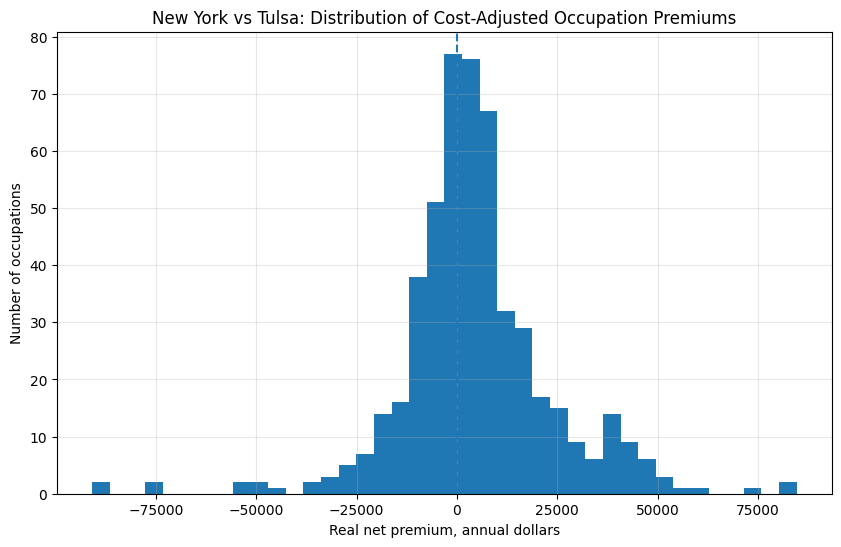

In [13]:
# Distribution of real net premiums across occupations

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(nyc_all_vs_tulsa["real_net_premium"].dropna(), bins=40)
ax.axvline(0, linestyle="--")
ax.set_title("New York vs Tulsa: Distribution of Cost-Adjusted Occupation Premiums")
ax.set_xlabel("Real net premium, annual dollars")
ax.set_ylabel("Number of occupations")
ax.grid(True, alpha=0.3)
plt.show()

## Compare multiple high-cost cities against multiple references

This section creates a small matrix of city-vs-reference comparisons.

Use it to see whether the result is specific to one comparison or structurally broader.

In [14]:
city_reference_pairs: list[tuple[str, str, str]] = [
    ("New York vs Tulsa", NYC, TULSA),
    ("New York vs Spokane", NYC, SPOKANE),
    ("San Francisco vs Tulsa", SF, TULSA),
    ("San Francisco vs Spokane", SF, SPOKANE),
    ("Los Angeles vs Tulsa", "31080", TULSA),
    ("Boston vs Tulsa", "14460", TULSA),
    ("Seattle vs Spokane", "42660", SPOKANE),
    ("Washington DC vs Tulsa", "47900", TULSA),
]

pair_summaries: list[pd.DataFrame] = []

for label, city, ref in city_reference_pairs:
    if city not in set(rpp["area"]) or ref not in set(rpp["area"]):
        print(f"Skipping {label}: missing RPP data.")
        continue

    try:
        result = employment_weighted_city_result(oews, rpp, city_area=city, reference_area=ref)
        summary = summarize_employment_weighted_result(result)
        summary["comparison"] = label
        pair_summaries.append(summary)
    except Exception as exc:
        print(f"Skipping {label}: {exc}")

pair_summary = (
    pd.concat(pair_summaries, ignore_index=True)
    .pivot(index="comparison", columns="metric", values="value")
    .reset_index()
)

display(pair_summary)

metric,comparison,employment_covered,employment_weighted_mean_real_net_premium,median_real_net_premium_unweighted,occupations_compared,share_employment_positive_nominal_premium,share_employment_positive_real_premium
0,Boston vs Tulsa,5261370.0,8957.275142,4179.226691,486.0,0.994918,0.816061
1,Los Angeles vs Tulsa,11997040.0,418.870078,-763.947475,508.0,0.911567,0.473455
2,New York vs Spokane,18246870.0,2621.979492,-734.551502,490.0,0.760924,0.423760
3,New York vs Tulsa,18273520.0,7285.695415,3031.059419,510.0,0.975903,0.716929
4,San Francisco vs Spokane,4672390.0,11561.262955,6558.266697,477.0,0.910136,0.763519
5,San Francisco vs Tulsa,4662470.0,15411.729781,9403.394703,490.0,0.998960,0.870204
6,Seattle vs Spokane,4060470.0,8102.333656,2934.695055,489.0,0.993850,0.762931
7,Washington DC vs Tulsa,885550.0,4245.531203,3059.357052,489.0,0.992818,0.647349


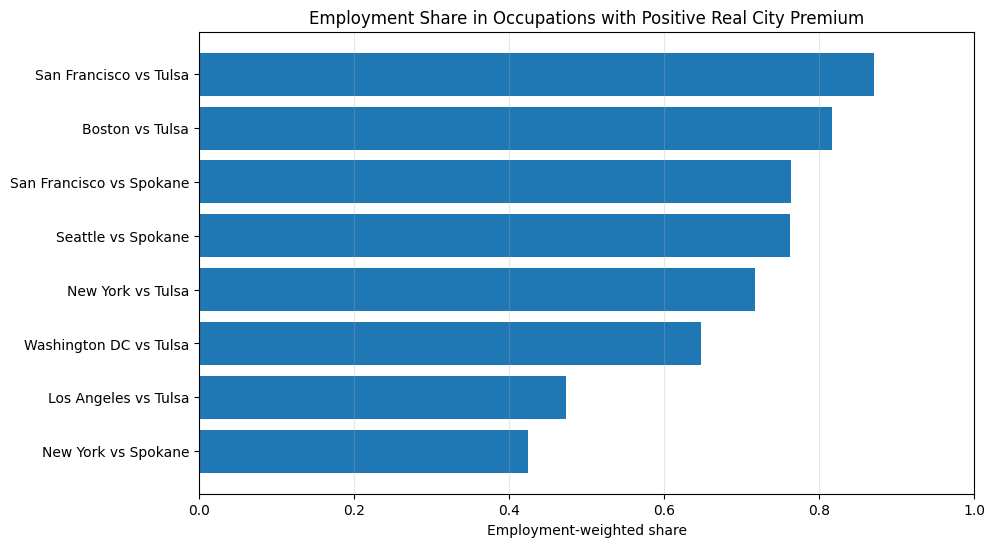

In [15]:
# Plot employment-weighted share with positive real premium

if not pair_summary.empty:
    plot_pairs = pair_summary.sort_values("share_employment_positive_real_premium")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        plot_pairs["comparison"],
        plot_pairs["share_employment_positive_real_premium"],
    )
    ax.set_title("Employment Share in Occupations with Positive Real City Premium")
    ax.set_xlabel("Employment-weighted share")
    ax.set_xlim(0, 1)
    ax.grid(True, axis="x", alpha=0.3)
    plt.show()

**The premium is not universal.** Reading nominal vs real side by side: almost
every occupation pays more in the big city *nominally* (the bars sit near 0.9&ndash;1.0),
but the **real** share is far lower and varies sharply by city. Against Tulsa,
San Francisco keeps **87%** of its workers ahead in real terms while **Los
Angeles keeps only 47%** &mdash; for a majority of LA workers the nominal raise
does not cover LA prices. The same nominal "city premium" can be decisive in one
metro and self-cancelling in another.

## Breakeven salary calculator

This section answers a personal version of the question:

> If I earn \(X\) in a cheaper place, what salary would I need in the city to have equal purchasing power?

The answer is:

\[
\text{needed city salary} =
\text{reference salary} \times
\frac{\text{RPP}_{city}}{\text{RPP}_{reference}}
\]

In [16]:
def breakeven_salary(
    reference_salary: float,
    city_area: str,
    reference_area: str,
    rpp_df: pd.DataFrame,
) -> float:
    """Calculate the city salary needed to match reference purchasing power."""
    if not isinstance(reference_salary, (int, float)) or reference_salary <= 0:
        raise ValueError("reference_salary must be a positive number.")

    city_area = str(city_area).zfill(5)
    reference_area = str(reference_area).zfill(5)

    rpp_lookup = rpp_df.set_index("area")["rpp_all"].to_dict()
    city_rpp = rpp_lookup[city_area]
    ref_rpp = rpp_lookup[reference_area]

    return float(reference_salary * city_rpp / ref_rpp)


reference_salaries = [40_000, 60_000, 80_000, 100_000, 150_000]

breakeven_table = pd.DataFrame(
    {
        "reference_salary_in_tulsa": reference_salaries,
        "needed_salary_in_new_york": [
            breakeven_salary(s, city_area=NYC, reference_area=TULSA, rpp_df=rpp)
            for s in reference_salaries
        ],
        "needed_salary_in_san_francisco": [
            breakeven_salary(s, city_area=SF, reference_area=TULSA, rpp_df=rpp)
            for s in reference_salaries
        ],
    }
)

display(breakeven_table)

,reference_salary_in_tulsa,needed_salary_in_new_york,needed_salary_in_san_francisco
0,40000,50468.760508,51836.258883
1,60000,75703.140763,77754.388325
2,80000,100937.521017,103672.517766
3,100000,126171.901271,129590.647208
4,150000,189257.851907,194385.970812


## Occupation-specific rankings

This section is useful for a data scientist, software engineer, nurse, teacher, retail worker, or administrative worker.

The same city can be good for one occupation and bad for another.

In [17]:
def rank_metros_for_occupation(
    wages: pd.DataFrame,
    rpp_df: pd.DataFrame,
    occ_code: str,
    min_employment: float = 100,
    top_n: int = 20,
) -> pd.DataFrame:
    """Rank metro areas for one occupation by real median wage."""
    assert_non_empty_string(occ_code, "occ_code")

    occ = wages.loc[
        (wages["occ_code"] == occ_code)
        & wages["is_cbsa_like"]
    ].copy()

    occ["a_median"] = safe_numeric(occ["a_median"])
    occ["tot_emp"] = safe_numeric(occ["tot_emp"])
    occ = occ.dropna(subset=["a_median", "tot_emp"])
    occ = occ.loc[occ["tot_emp"] >= min_employment]

    ranked = (
        occ.merge(rpp_df[["area", "rpp_all", "rpp_rent"]], on="area", how="inner")
        .assign(real_a_median=lambda x: x["a_median"] / (x["rpp_all"] / 100.0))
        .sort_values("real_a_median", ascending=False)
        .reset_index(drop=True)
    )

    return ranked.head(top_n)


for occ_code, occ_name in FOCUS_OCCUPATIONS.items():
    if occ_code == "00-0000":
        continue

    print(f"\nTop metros for {occ_name} ({occ_code}) by cost-adjusted annual median wage")
    ranked = rank_metros_for_occupation(oews, rpp, occ_code=occ_code, min_employment=100, top_n=10)
    display(ranked[["area", "area_title", "tot_emp", "a_median", "rpp_all", "real_a_median"]])


Top metros for Data Scientists (15-2051) by cost-adjusted annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",6570.0,173160.0,110.423,156815.156263
1,41860,"San Francisco-Oakland-Fremont, CA",9350.0,166300.0,115.613,143841.955489
2,42660,"Seattle-Tacoma-Bellevue, WA",6100.0,157290.0,111.133,141533.117976
3,16740,"Charlotte-Concord-Gastonia, NC-SC",3870.0,131110.0,97.348,134681.760283
4,34980,"Nashville-Davidson--Murfreesboro--Franklin, TN",1490.0,127770.0,96.338,132626.793166
5,14860,"Bridgeport-Stamford-Danbury, CT",370.0,139660.0,106.864,130689.474472
6,44140,"Springfield, MA",260.0,123810.0,96.061,128886.853145
7,45940,"Trenton-Princeton, NJ",370.0,130590.0,103.180,126565.225819
8,12420,"Austin-Round Rock-San Marcos, TX",3100.0,122440.0,98.066,124854.689699
9,47900,"Washington-Arlington-Alexandria, DC-VA-MD-WV",8530.0,135190.0,108.884,124159.656148



Top metros for Software Developers (15-1252) by cost-adjusted annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",90280.0,208270.0,110.423,188611.068346
1,42660,"Seattle-Tacoma-Bellevue, WA",72730.0,169340.0,111.133,152375.981932
2,14500,"Boulder, CO",7790.0,159670.0,105.202,151774.681090
3,41860,"San Francisco-Oakland-Fremont, CA",76900.0,174910.0,115.613,151289.214881
4,42200,"Santa Maria-Santa Barbara, CA",2030.0,163020.0,108.798,149837.313186
5,14860,"Bridgeport-Stamford-Danbury, CT",3800.0,157540.0,106.864,147421.021111
6,35620,"New York-Newark-Jersey City, NY-NJ",119610.0,161970.0,112.563,143892.753391
7,14460,"Boston-Cambridge-Newton, MA-NH",48200.0,154240.0,108.266,142463.931428
8,41740,"San Diego-Chula Vista-Carlsbad, CA",21080.0,159240.0,111.887,142322.164327
9,38900,"Portland-Vancouver-Hillsboro, OR-WA",16620.0,149010.0,105.421,141347.549350



Top metros for Registered Nurses (29-1141) by cost-adjusted annual median wage


...

,area,area_title,tot_emp,a_median,rpp_all,real_a_median
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",17420.0,43040.0,110.423,38977.386957
1,43620,"Sioux Falls, SD-MN",5340.0,34260.0,90.631,37801.635202
2,41860,"San Francisco-Oakland-Fremont, CA",37380.0,42490.0,115.613,36751.922362
3,28140,"Kansas City, MO-KS",24630.0,33840.0,92.543,36566.785170
4,44140,"Springfield, MA",4590.0,34980.0,96.061,36414.361708
5,38860,"Portland-South Portland, ME",8460.0,36890.0,101.858,36217.086532
6,42220,"Santa Rosa-Petaluma, CA",5120.0,38760.0,107.784,35960.810510
7,24580,"Green Bay, WI",4010.0,33390.0,93.086,35870.055647
8,14500,"Boulder, CO",5000.0,37720.0,105.202,35854.831657
9,45060,"Syracuse, NY",7940.0,34320.0,95.742,35846.337031



Top metros for Fast Food and Counter Workers (35-3023) by cost-adjusted annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",21320.0,42660.0,110.423,38633.255753
1,47300,"Visalia, CA",4860.0,36390.0,99.825,36453.794140
2,12540,"Bakersfield-Delano, CA",9400.0,36440.0,100.886,36119.977004
3,33700,"Modesto, CA",7250.0,37430.0,104.108,35953.048757
4,15380,"Buffalo-Cheektowaga, NY",14200.0,34240.0,95.844,35724.719336
5,45060,"Syracuse, NY",7070.0,33910.0,95.742,35418.102818
6,42220,"Santa Rosa-Petaluma, CA",5160.0,38090.0,107.784,35339.196912
7,40900,"Sacramento-Roseville-Folsom, CA",25790.0,37650.0,106.670,35295.772007
8,41860,"San Francisco-Oakland-Fremont, CA",47330.0,40470.0,115.613,35004.714003
9,44140,"Springfield, MA",5040.0,33580.0,96.061,34956.954435



Top metros for Home Health and Personal Care Aides (31-1120) by cost-adjusted annual median wage


,area,area_title,tot_emp,a_median,rpp_all,real_a_median
0,44060,"Spokane-Spokane Valley, WA",9980.0,46030.0,100.346,45871.285353
1,38900,"Portland-Vancouver-Hillsboro, OR-WA",22190.0,44320.0,105.421,42040.959581
2,42660,"Seattle-Tacoma-Bellevue, WA",53140.0,46690.0,111.133,42012.723493
3,44140,"Springfield, MA",15220.0,39520.0,96.061,41140.525291
4,43620,"Sioux Falls, SD-MN",1510.0,36970.0,90.631,40791.782061
5,14500,"Boulder, CO",1620.0,42360.0,105.202,40265.394194
6,41420,"Salem, OR",5520.0,40520.0,103.649,39093.478953
7,39300,"Providence-Warwick, RI-MA",16400.0,39520.0,101.773,38831.517200
8,19780,"Des Moines-West Des Moines, IA",5620.0,35480.0,91.701,38690.963021
9,49340,"Worcester, MA",14380.0,39520.0,102.523,38547.447890


**Reading the occupation rankings.** The cost-adjusted leader board is not the
nominal one. For **data scientists**, San Jose tops both, but mid-size, sub-100
price-level metros &mdash; **Charlotte** and **Nashville** &mdash; outrank every
coastal hub except the top three once prices are netted out. For **registered
nurses**, the real top six is an all-California sweep, including cheaper inland
metros like **Modesto** and **Bakersfield**: California pays nurses enough that
even its expensive metros win on purchasing power. The lesson is occupation-
specific &mdash; the best *real* city for a nurse is not the best one for a
software developer.

## Save outputs

The comparative notebook (`04_comparative_framework_us_uk_eu.ipynb`) reads the
metro-level table saved here. We persist the full city table plus a compact
employment-weighted summary of the city-vs-reference matrix.

In [18]:
us_metro_output = metro_real[[
    "area",
    "area_title",
    "tot_emp",
    "a_median",
    "a_mean",
    "rpp_all",
    "rpp_rent",
    "real_a_median",
    "real_a_mean",
    "rent_pressure_index",
]].copy()
us_metro_output["oews_year"] = OEWS_YEAR
us_metro_output["rpp_year"] = RPP_YEAR

metro_path = OUTPUT_DIR / "us_city_wage_cost_analysis.csv"
us_metro_output.to_csv(metro_path, index=False)
print(f"Saved: {metro_path}  ({len(us_metro_output)} metros)")

if not pair_summary.empty:
    pair_path = OUTPUT_DIR / "us_city_vs_reference_summary.csv"
    pair_summary.to_csv(pair_path, index=False)
    print(f"Saved: {pair_path}  ({len(pair_summary)} comparisons)")

Saved: C:\Users\diogo\work_code\ds-projects-portfolio\projects\city_wage_cost_global\outputs\us_city_wage_cost_analysis.csv  (145 metros)
Saved: C:\Users\diogo\work_code\ds-projects-portfolio\projects\city_wage_cost_global\outputs\us_city_vs_reference_summary.csv  (8 comparisons)


## Optional: manually add MIT Living Wage data for up to 10 locations

MIT's Living Wage Calculator is useful because it models a survival budget by household type.

However, the public website should not be scraped or bulk exported. Their FAQ allows direct web use for 10 or fewer locations, with citation, but says not to scrape/export the site for more than 10 locations.

So the ethical approach is:

1. use this notebook's BLS + BEA/FRED analysis for scalable metro comparisons;
2. manually enter MIT Living Wage values for a few case-study locations;
3. license the data if you want a full national living-wage dataset.

Use the template below only for hand-entered values.

In [19]:
# Optional manual MIT Living Wage values.
# Fill this by hand for at most a small number of locations.
# Example columns:
# - annual_living_wage_single_adult_no_children
# - annual_living_wage_two_adults_one_child
#
# Do not scrape the MIT Living Wage Calculator website.

manual_living_wage = pd.DataFrame(
    columns=[
        "area",
        "area_title",
        "household_type",
        "annual_living_wage",
        "source_note",
    ]
)

display(manual_living_wage)

,area,area_title,household_type,annual_living_wage,source_note


## Conclusion: what the 2024 data shows

Using BLS OEWS (May 2024) and BEA Regional Price Parities (2024) across the
**145 metros** that have a published RPP, the evidence supports a *conditional*
version of the claim. The city premium is real for some workers and an illusion
for others, and which one you get depends on your occupation and on which two
places you compare.

**1. Nominal and real rankings mostly agree at the very top, but not entirely.**
Nominal and cost-adjusted all-occupation median wages correlate at **r &asymp; 0.87**.
San Jose leads on *both* (nominal \$82.5k, real \$74.7k): its tech-driven wages
clear a 110 price level. But the adjustment reshuffles the board below it. San
Francisco has the highest coastal wages yet the highest price level too (RPP
115.6), so it falls behind lower-cost **Boulder** in real terms.
**Durham&ndash;Chapel Hill** (RPP 97.6) climbs *into* the real top eight purely
because it is cheaper than average.

**2. The clearest losers are "expensive but low-paying" metros.** **Miami** is
the textbook case: the 2nd-most-expensive metro in the sample (RPP 114.2) but a
median wage of only \$47.9k, giving a real median of \$42.0k &mdash; near the
national bottom, alongside McAllen, El Paso and Salinas. High prices with
ordinary wages is the worst combination.

**3. Whether the premium survives is an employment-weighted coin-flip in some
cities.** Nearly every occupation pays more *nominally* in a big city than in
Tulsa (91&ndash;99% of city employment). After the price adjustment:

| Comparison | Positive **nominal** premium | Positive **real** premium | Mean real premium |
|---|---|---|---|
| **San Francisco** vs Tulsa | 99.9% | **87%** | +\$15,412 |
| **New York** vs Tulsa | 97.6% | **72%** | +\$7,286 |
| **Los Angeles** vs Tulsa | 91.2% | **47%** | **+\$419** |

In Los Angeles the nominal premium is largely a mirage: by employment, *most*
workers are no better off than in Tulsa, and the average real gain rounds to
zero. San Francisco is where the premium genuinely holds.

**4. The split is occupational.** New York vs Tulsa, by real net premium:
elementary teachers **+\$32.8k**, data scientists **+\$28.6k**, software
developers **+\$24.2k**, registered nurses **+\$9.9k** &mdash; but retail
salespersons **&minus;\$489** (a real *loss* despite a \$7.4k nominal raise),
fast-food **+\$2.2k**, home-health aides **+\$3.6k**. High-skill workers capture
a large real premium; low-wage service workers see most or all of it eaten by
local prices.

**5. For high earners, lower-cost cities can beat the coasts.** For data
scientists, San Jose still wins, but **Charlotte** and **Nashville** (both
RPP < 100) outrank every coastal metro except the top three on a cost-adjusted
basis. For registered nurses, California sweeps the real top six &mdash; even
cheaper inland metros like **Modesto** beat San Francisco, because California
nurse pay is high statewide.

> **Bottom line.** A large city does not automatically make a worker richer. It
> reliably raises *nominal* pay, but the real gain is concentrated in high-skill
> occupations and in cities (San Francisco, San Jose) where wages outrun an
> already-high cost of living. For median and low-wage service workers, and in
> "expensive but ordinary-paying" metros like Miami or Los Angeles, the city
> premium is small, zero, or negative.

## Possible extensions

Good next steps:

1. Add Census ACS rent and household income data by metro.
2. Add tax simulations by state and household type.
3. Add household-specific scenarios: single adult, couple, family with children.
4. Add migration flows to test whether people vote with their feet.
5. Add career ladder effects by occupation.
6. Compare metro cores with suburbs, because MSA averages hide within-city housing inequality.
7. Build a causal design using movers, if suitable microdata is available.